In [ ]:
# Parameters
eval_start = "2024-08-01"
eval_end = "2024-10-15"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

params_path_new = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28.npz'
norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/gc_norms/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 65, 95
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'


In [2]:
"""
Complete evaluation of forecast against different datasets
"""
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm.notebook import tqdm
import time
import zarr
import matplotlib.pyplot as plt
# import pynvml

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn
print(sys.path)
sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg

# current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# # jax.config.update('jax_disable_jit', True)
# # for memory efficiency
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# mean_by_level = None
# stddev_by_level = None
# diffs_stddev_by_level = None
# model_config = None
# task_config = None
# params = None
# state = None

['/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/local_files', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python311.zip', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/lib-dynload', '', '/home/saptarishi.dhanuka_asp25/.local/lib/python3.11/site-packages', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/eccc_rpnpy-2.2.0rc3-py3.11.egg', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/fstd2nc-0.20240401.0-py3.11.egg', '/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast', '/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast']


In [3]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/hres_2024_8_8_ppt_6hourly.grib')
hres

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 871MB
Dimensions:     (step: 29, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 232B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 766MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-14T18:55 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)
regridded_hres

Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


<xarray.DataArray 'tp' (step: 29, lat: 181, lon: 360)> Size: 8MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[3.81469727e-06, 3.81469727e-06, 3.81469727e-06, ...,
         3.81469727e-06, 3.81469727e-06, 3.81469727e-06],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.62939453e-06, 7.62939453e-06, 3.81469727e-06, ...,
         7.62939453e-06, 7.62939453e-06, 7.62939453e-06],
...
        [5.11169434e-03, 5.11169434e-03, 6.77490234e-03, ...,
         4.27246094e-03, 4.27246094e-03, 5.11169434e-03],
        [1.01165771e-02, 1.01165771e-02, 1.01165771e-02, ...,
         7.85827637e-03, 1.01165771e-02, 1.01165771e-02],
        [5.56945801e-03, 5.56945801e-03, 5.56945801e-03, ...,
         5.56945801e-03, 5.56945801e-03, 5.56945801e-03]],

       [[2.89916992e-04, 2.89916992e-04, 2.89916992e-04, ...,
         2.89916992e-04, 2.89916992e-04, 2.89916992e-04],
        [2.28881836e-04, 2.28881836e-04, 2.28881836e-04, ...,
         2.28881836e-04, 2.28881836e-04, 2.28881836e-04],
        [9.15527344e-05, 9.15527344e-05, 1.06811523e-04, ...,
         7.62939453e-05, 7.62939453e-05, 9.15527344e-05],
        ...,
        [5.11169434e-03, 5.11169434e-03, 6.77490234e-03, ...,
         4.27246094e-03, 4.27246094e-03, 5.11169434e-03],
        [1.01470947e-02, 1.01470947e-02, 1.01470947e-02, ...,
         7.88879395e-03, 1.01470947e-02, 1.01470947e-02],
        [5.67626953e-03, 5.67626953e-03, 5.67626953e-03, ...,
         5.67626953e-03, 5.67626953e-03, 5.67626953e-03]]], dtype=float32)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2024-08-08
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 232B 2024-08-08 ... 2024-08-15
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             6599680
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d

In [5]:
select_time_evals = []

if dataset_choice == "imerg":
    apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/'
    dbase,_ = trainer.dataloader.open_databases(apath,None) # Note no need for a separate verification dbase
    dbase = construct_era5_imerg(dbase)
    eval_time_ds = dbase.sel(time=slice(eval_start, eval_end))
    # del dbase


input_vars = ['10m_u_component_of_wind',
            'geopotential_at_surface',
            '10m_v_component_of_wind',
            'specific_humidity',
            'land_sea_mask',
            'vertical_velocity',
            'geopotential',
            'v_component_of_wind',
            'temperature',
            'total_precipitation_6hr',
            'mean_sea_level_pressure',
            '2m_temperature',
            'u_component_of_wind']

eval_time_ds = eval_time_ds.expand_dims(batch=1)
eval_time_ds = eval_time_ds.rename({'latitude': 'lat', 'longitude': 'lon'})

datetime_array = eval_time_ds['time'].values
# Calculate the time coordinate in 6-hour increments (in nanoseconds)
time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

# Add the new 'time' coordinate to the dataset
final_eval_ds = eval_time_ds.assign_coords(datetime=('time', time_array))

temp_time = final_eval_ds.coords["time"].copy()
temp_datetime = final_eval_ds.coords["datetime"].copy()

# Reassign the coordinates, swapping their values
final_eval_ds = final_eval_ds.assign_coords(
    time=temp_datetime,
    datetime=temp_time
)

# final_eval_ds['geopotential_at_surface'] = final_eval_ds['geopotential_at_surface'].isel(batch=0, time=0)
# final_eval_ds['land_sea_mask'] = final_eval_ds['land_sea_mask'].isel(batch=0, time=0)

old_datetime = final_eval_ds["datetime"].values  # shape (1489,)

# For our purposes, we want the coordinate to have shape (batch, time). Since the batch
# dimension is of length 1, we can simply add a new axis.
new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

# Now, reassign the "datetime" coordinate to have dims ("batch", "time").
final_eval_ds = final_eval_ds.assign_coords(datetime=(("batch", "time"), new_datetime))

print(f"Coordinates after reassigning: {final_eval_ds.coords}\n")
final_eval_ds

Found ['/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/02', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/03', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/04', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/05', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/06', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/07', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/08', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/09', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/10', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/11', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/12', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/02', '/Datastorage

Looping through era5 days for conversion:  40%|███▉      | 348/871 [00:00<00:00, 1732.69it/s]

Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-25 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-26 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-27 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-28 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-29 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-30 00:00:00')
Info: used IMERG data from 2024-01-01 00:00:00 for target Timestamp('2023-12-31 00:00:00')


Looping through era5 days for conversion:  83%|████████▎ | 720/871 [00:06<00:01, 108.36it/s] 


Exceeded IMERG timespan, stopped replacing with IMERG
Skipping 2023-01-01 00:00:00: no IMERG data for 2023-01-01 00:00:00
Skipping 2023-01-01 06:00:00: no IMERG data for 2023-01-01 00:00:00
Skipping 2023-01-01 12:00:00: no IMERG data for 2023-01-01 00:00:00
Skipping 2023-01-01 18:00:00: no IMERG data for 2023-01-01 00:00:00
Skipping 2023-01-02 00:00:00: no IMERG data for 2023-01-02 00:00:00
Skipping 2023-01-02 06:00:00: no IMERG data for 2023-01-02 00:00:00
Skipping 2023-01-02 12:00:00: no IMERG data for 2023-01-02 00:00:00
Skipping 2023-01-02 18:00:00: no IMERG data for 2023-01-02 00:00:00
Skipping 2023-01-03 00:00:00: no IMERG data for 2023-01-03 00:00:00
Skipping 2023-01-03 06:00:00: no IMERG data for 2023-01-03 00:00:00
Skipping 2023-01-03 12:00:00: no IMERG data for 2023-01-03 00:00:00
Skipping 2023-01-03 18:00:00: no IMERG data for 2023-01-03 00:00:00
Skipping 2023-01-04 00:00:00: no IMERG data for 2023-01-04 00:00:00
Skipping 2023-01-04 06:00:00: no IMERG data for 2023-01-04 00:

<xarray.Dataset> Size: 18GB
Dimensions:                  (batch: 1, time: 304, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 2kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 2kB 0 days 00:00:00 ... 7...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
select_time_eval = final_eval_ds
select_time_eval

<xarray.Dataset> Size: 18GB
Dimensions:                  (batch: 1, time: 304, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 2kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 2kB 0 days 00:00:00 ... 7...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 79MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [7]:
data_len = len(select_time_eval.time.values)
data_len

304

In [8]:
select_time_evals = []
for time_slice in range(0, data_len, 28):
    select_time_evals.append(select_time_eval.isel(time=slice(time_slice, time_slice+28)))

In [9]:
for ds in select_time_evals:
    print(ds.datetime.values[0][0])

2024-08-01T00:00:00.000000000
2024-08-08T00:00:00.000000000
2024-08-15T00:00:00.000000000
2024-08-22T00:00:00.000000000
2024-08-29T00:00:00.000000000
2024-09-05T00:00:00.000000000
2024-09-12T00:00:00.000000000
2024-09-19T00:00:00.000000000
2024-09-26T00:00:00.000000000
2024-10-03T00:00:00.000000000
2024-10-10T00:00:00.000000000


In [10]:
sims = len(select_time_evals)
sims

11

In [11]:
eval_trial_batches = []
from dask.diagnostics import ProgressBar
for i in tqdm(range(sims-1)):
    with ProgressBar():
        eval_trial_batches.append(select_time_evals[i].load())

  0%|          | 0/10 [00:00<?, ?it/s]

[                                        ] | 0% Completed | 278.89 ms

[########################################] | 100% Completed | 1.79 sms
[########################################] | 100% Completed | 1.62 sms
[########################################] | 100% Completed | 1.66 sms
[########################################] | 100% Completed | 1.65 sms
[########################################] | 100% Completed | 1.73 sms
[########################################] | 100% Completed | 1.65 sms
[########################################] | 100% Completed | 1.73 sms
[########################################] | 100% Completed | 1.70 sms
[########################################] | 100% Completed | 1.71 sms
[########################################] | 100% Completed | 1.70 sms


In [12]:
# print(f"Eval batch first time: {eval_trial_batch.time.values[0]}")


with open(params_path_old, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params

with open(f'{norms_dir}diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()

state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
'params': ckpt.params,
'state': {},
'model_config': ckpt.model_config,
'task_config': ckpt.task_config,
'mean_by_level': mean_by_level,
'stddev_by_level': stddev_by_level,
'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets_template,
    forcings=forcings,
    params=params,
    state=state
)
    return predictions

In [2]:
# need to make sure that the .npz and the .opt are both new and .opt isnt the old one
import os
import numpy as np
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from graphcast import checkpoint, graphcast

f = open("/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28_dynamic_weighing_expt1_india_mask.npz", "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params
f.close()
params_keys_list = list(new_params.keys())
any_not_nan = any(not np.isnan(x) for x in list(new_params[f'{params_keys_list[0]}'].values())[1])
if not any_not_nan:
    print("All values are NaN")
else:
    print("Valid values are there!")
!ls -lth /Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz

Valid values are there!
-rw-r--r-- 1 saptarishi.dhanuka_asp25 saptarishi.dhanuka_asp25 138M Jul  5 06:56 /Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz


In [14]:
eval_sim_data = eval_trial_batches[0]
eval_sim_data

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 448B '0001' '0001' ... '0001' '0001'
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 224B 2024-08-01 ......
  * time                     (time) timedelta64[ns] 224B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB 4.121 ... 4.581
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB -3.601 ... -...
    2m_temperature           (batch, time, lat, lon) float32 7MB 226.5 ... 272.8
    geopotential             (batch, time, level, lat, lon) float32 270MB 4.1...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.772e+04 ... -1.24
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 270MB 3.9...
    temperature              (batch, time, level, lat, lon) float32 270MB 258...
    u_component_of_wind      (batch, time, level, lat, lon) float32 270MB 8.3...
    v_component_of_wind      (batch, time, level, lat, lon) float32 270MB 2.2...
    vertical_velocity        (batch, time, level, lat, lon) float32 270MB -0....
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB 5.722e-06 .....
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [15]:
from plotting import compute_difference_with_targets_sims
from utils import compute_mse, compute_mse_diffs

In [16]:
time_len = len(eval_trial_batches[0].time.values)
eval_sim_data = eval_trial_batches[0].isel(time=slice(0, time_len-1))
eval_sim_data

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 27, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 432B '0001' '0001' ... '0001' '0001'
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 216B 2024-08-01 ......
  * time                     (time) timedelta64[ns] 216B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB 4.121 ... 1.782
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB -3.601 ... -...
    2m_temperature           (batch, time, lat, lon) float32 7MB 226.5 ... 273.0
    geopotential             (batch, time, level, lat, lon) float32 260MB 4.1...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.772e+04 ... -1.24
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 260MB 3.9...
    temperature              (batch, time, level, lat, lon) float32 260MB 258...
    u_component_of_wind      (batch, time, level, lat, lon) float32 260MB 8.3...
    v_component_of_wind      (batch, time, level, lat, lon) float32 260MB 2.2...
    vertical_velocity        (batch, time, level, lat, lon) float32 260MB -0....
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB 5.722e-06 .....
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [17]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_sim_data, target_lead_times=slice("6h", "144h"),
**dataclasses.asdict(task_config))
forecast_len = len(eval_targets.time.values)

In [18]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/hres_2024_8_1_ppt_6hourly.grib')
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)
precip_ds1 = eval_targets['total_precipitation_6hr']

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


In [19]:
import glob
from datetime import datetime

# List all files (any type) in a directory
file_list = glob.glob("/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/*.grib")

# Helper function to extract (month, day) and convert to datetime
def extract_month_day(path):
    parts = path.split('_')
    # print(parts)
    year = 2024  # fixed, or extract if you want dynamic
    month = int(parts[5])
    day = int(parts[6])
    return datetime(year, month, day)

# Sort based on extracted datetime
sorted_paths = sorted(file_list, key=extract_month_day)

# Print sorted list
for path in sorted_paths[5:11]:
    print(path[-25:-5])

2024_9_5_ppt_6hourly
024_9_12_ppt_6hourly
024_9_19_ppt_6hourly
024_9_26_ppt_6hourly
024_10_3_ppt_6hourly
24_10_10_ppt_6hourly


In [20]:
i = 1
hres_file = sorted_paths[i]
hres_file

'/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2024/hres_2024_8_8_ppt_6hourly.grib'

In [21]:

params_path_new1 = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-09-15_FORECAST28.npz"
params_path_new2 = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28.npz"
f = open(params_path_new1, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params1 = new_ckpt.params
f.close()


f = open(params_path_new2, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params2 = new_ckpt.params
f.close()


In [22]:
time_len = len(eval_trial_batches[i].time.values)
eval_sim_data = eval_trial_batches[i].isel(time=slice(0, time_len-1))
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_sim_data, target_lead_times=slice("6h", "100h"),
**dataclasses.asdict(task_config))
forecast_len = len(eval_targets.time.values)

assert eval_trial_batches[i].sizes["time"] >= 3

print(f"Eval batch time dimensions: {eval_trial_batches[i].sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

print("Running new params")

predictions_finetuned1 = run_model(new_params1, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned1: ", predictions_finetuned1.dims.mapping)

predictions_finetuned2 = run_model(new_params2, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Finetuned2: ", predictions_finetuned2.dims.mapping)

Eval batch time dimensions: 28
Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned1:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Predictions Finetuned2:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [23]:
hres = xr.open_dataset(hres_file)
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)

Regridding tp from high resolution to coarse resolution 1.0 degrees


/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridder built


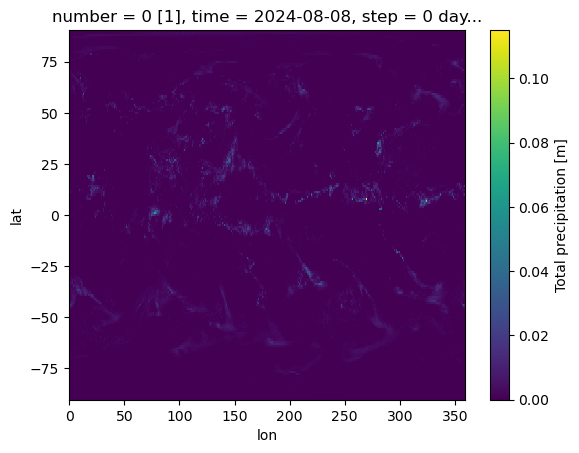

In [24]:
regridded_hres.isel(step=i).plot()

In [25]:
eval_targets['total_precipitation_6hr'].isel(time=i).squeeze(dim='batch')

<xarray.DataArray 'total_precipitation_6hr' (lat: 181, lon: 360)> Size: 261kB
array([[9.0122223e-05, 9.0122223e-05, 9.0122223e-05, ..., 9.0122223e-05,
        9.0122223e-05, 9.0122223e-05],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [6.5812527e-04, 6.5406272e-04, 6.7593763e-04, ..., 6.3906278e-04,
        6.1156286e-04, 6.5750029e-04],
       [3.3937491e-04, 3.0687492e-04, 3.1437492e-04, ..., 3.1062495e-04,
        3.1499992e-04, 3.1562490e-04],
       [4.7683716e-06, 4.7683716e-06, 4.7683716e-06, ..., 4.7683716e-06,
        4.7683716e-06, 4.7683716e-06]], dtype=float32)
Coordinates:
    expver   <U4 16B '0001'
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B 0
    time     timedelta64[ns] 8B 16:00:00
Attributes:
    source:             IMERG daily precipitation converted to 6‑hourly accum...
    original_source:    GPM IMERG Final Precipitation L3 1 day 0.1°×0.1° V07
    conversion_method:  Daily rate (mm/day) → 6‑hr accum. (m), ERA5 used wher...
    units:              m

In [26]:
diff_fine1, diff_fine2, diff_old, diff_hres = [], [], [], []
for time_step in tqdm(range(forecast_len), desc='Diff compute over timesteps'):
    diff_fine1.append(compute_difference_with_targets_sims(predictions_finetuned1,eval_targets,time_step, 'total_precipitation_6hr', plot=True))
    diff_fine2.append(compute_difference_with_targets_sims(predictions_finetuned2,eval_targets,time_step, 'total_precipitation_6hr', plot=True))
    diff_old.append(compute_difference_with_targets_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr', plot=True))
    diff_hres.append(regridded_hres.isel(step=time_step) - eval_targets['total_precipitation_6hr'].isel(time=time_step).squeeze(dim='batch'))

Diff compute over timesteps:   0%|          | 0/16 [00:00<?, ?it/s]

In [27]:
# Compute the MSE for each time step and aggregate
mse_finetuned1 = []
mse_finetuned2 = []

mse_base = []
mse_hres =[]
for diff_counter in tqdm(range(min(len(diff_fine1), len(diff_hres)))):
    mse_diff_fine1tuned = compute_mse_diffs(diff_fine1[diff_counter])
    mse_diff_fine2tuned = compute_mse_diffs(diff_fine2[diff_counter])
    
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])

    mse_diff_hres = compute_mse_diffs(diff_hres[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned1.append(mse_diff_fine1tuned)
    mse_finetuned2.append(mse_diff_fine2tuned)
    mse_base.append(mse_diff_base)
    mse_hres.append(mse_diff_hres)

  0%|          | 0/16 [00:00<?, ?it/s]

[array(6.5466675e-06, dtype=float32), array(8.813709e-06, dtype=float32), array(8.695889e-06, dtype=float32), array(8.05441e-06, dtype=float32), array(7.646798e-06, dtype=float32), array(1.2777402e-05, dtype=float32), array(1.1287537e-05, dtype=float32), array(1.1889378e-05, dtype=float32), array(1.0548905e-05, dtype=float32), array(1.9764871e-05, dtype=float32), array(1.9865956e-05, dtype=float32), array(2.2453276e-05, dtype=float32), array(1.8863346e-05, dtype=float32), array(2.0387231e-05, dtype=float32), array(2.0331036e-05, dtype=float32), array(2.3721434e-05, dtype=float32)]
Mse finetuned 1
[array(3.856588e-06, dtype=float32), array(7.430546e-06, dtype=float32), array(7.1380364e-06, dtype=float32), array(6.3789257e-06, dtype=float32), array(6.5670224e-06, dtype=float32), array(1.041648e-05, dtype=float32), array(8.8638635e-06, dtype=float32), array(8.383782e-06, dtype=float32), array(7.9913e-06, dtype=float32), array(1.5226984e-05, dtype=float32), array(1.3129425e-05, dtype=float

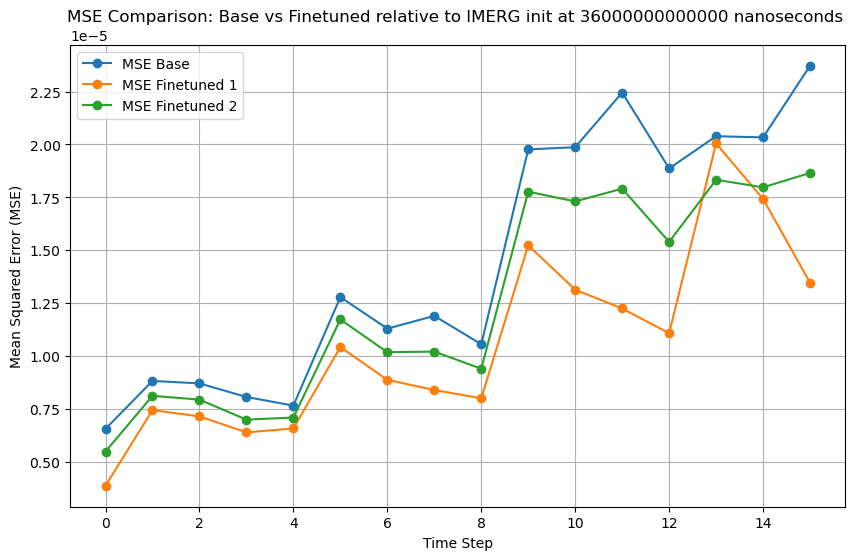

In [28]:
print(mse_base)
print(f"Mse finetuned 1")
print(mse_finetuned1)
print(f"Mse finetuned 2")
print(mse_finetuned2)
print(f"Mse hres")
# print(mse_hres)
mse_hres_new = [np.array(x.item(), dtype=np.float32) for x in mse_hres]
print(mse_hres_new)

print(f"\n Forecast length is: {forecast_len} \n")


# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned1, label='MSE Finetuned 1', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned2, label='MSE Finetuned 2', marker='o')
# plt.plot(list(range(len((mse_hres_new)))), mse_hres_new, label='HRES', marker='o')

plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned relative to IMERG init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
forecast_len = len(precip_ds1.time.values)
forecast_len

24

In [30]:
diff_hres = []
for i in tqdm(range(forecast_len)):
    diff_hres.append(regridded_hres.isel(step=i) - precip_ds1.isel(time=i))


  0%|          | 0/24 [00:00<?, ?it/s]

In [31]:
from utils import compute_mse_diffs

[array([4.421835e-06], dtype=float32), array([7.9375395e-06], dtype=float32), array([1.792846e-05], dtype=float32), array([3.20236e-05], dtype=float32), array([4.8146216e-05], dtype=float32), array([6.650826e-05], dtype=float32), array([8.6104345e-05], dtype=float32), array([0.00010787], dtype=float32), array([0.00013161], dtype=float32), array([0.0001551], dtype=float32), array([0.00018368], dtype=float32), array([0.00021624], dtype=float32), array([0.00025019], dtype=float32), array([0.00028479], dtype=float32), array([0.00032125], dtype=float32), array([0.00036015], dtype=float32), array([0.00040253], dtype=float32), array([0.00044782], dtype=float32), array([0.00049324], dtype=float32), array([0.00053992], dtype=float32), array([0.00058751], dtype=float32), array([0.00062776], dtype=float32), array([0.00067652], dtype=float32), array([0.00072835], dtype=float32)]


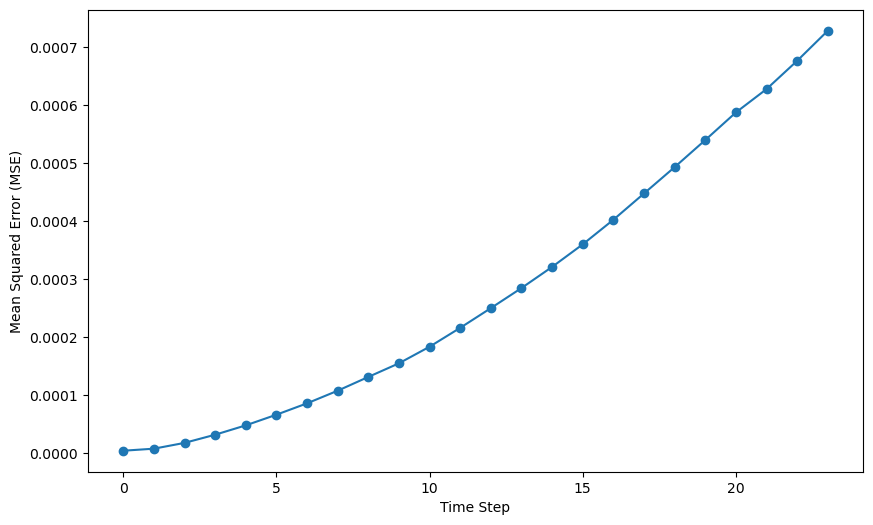

In [32]:
mse_hres = []
for diff_counter in range(len(diff_hres)):
    mse_diff_hres = compute_mse_diffs(diff_hres[diff_counter])

    
    mse_hres.append(mse_diff_hres)

print(mse_hres)

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_hres, label='MSE HRES', marker='o')
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.show()

In [33]:
mse_hres.shape

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# Select the data at the 6-hour mark.
# We use .sel() to select by coordinate value.
six_hour_forecast = precip_ds1.sel(time=pd.to_timedelta('6 hours'))
six_hour_forecast

<xarray.DataArray 'total_precipitation_6hr' (batch: 1, lat: 181, lon: 360)> Size: 261kB
array([[[1.7166138e-05, 1.7166138e-05, 1.7166138e-05, ...,
         1.7166138e-05, 1.7166138e-05, 1.7166138e-05],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [3.1249999e-06, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 6.2499998e-06],
        [4.1343734e-04, 4.2281236e-04, 4.3187483e-04, ...,
         4.0781236e-04, 4.0687484e-04, 3.8437487e-04],
        [1.9121170e-04, 1.9121170e-04, 1.9121170e-04, ...,
         1.9121170e-04, 1.9121170e-04, 1.9121170e-04]]], dtype=float32)
Coordinates:
    expver   <U4 16B '0001'
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B 0
    time     timedelta64[ns] 8B 06:00:00
Dimensions without coordinates: batch
Attributes:
    source:             IMERG daily precipitation converted to 6‑hourly accum...
    original_source:    GPM IMERG Final Precipitation L3 1 day 0.1°×0.1° V07
    conversion_method:  Daily rate (mm/day) → 6‑hr accum. (m), ERA5 used wher...
    units:              m

In [ ]:

# The result has a 'batch' dimension of size 1. We remove it with .squeeze()
# so its dimensions (lat, lon) match the spatial dimensions of ds2.
six_hour_forecast_squeezed = six_hour_forecast.squeeze('batch')

# The second dataset is already our target variable 'tp'
precip_ds2 = regridded_hres

print("\nShape of the 6-hour forecast data from ds1:", six_hour_forecast_squeezed.shape)
print("Shape of the hourly 'tp' data from ds2:", precip_ds2.shape)


# --- 3. Compute the Mean Squared Error (MSE) ---
print("\nStep 3: Calculating Mean Squared Error per step...")

# Xarray will automatically align and broadcast the 'six_hour_forecast_squeezed' array
# across the 'step' dimension of 'precip_ds2' during the subtraction.
squared_error = (six_hour_forecast_squeezed - precip_ds2)**2

# Now, compute the mean over the spatial dimensions ('lat', 'lon') to get
# a single MSE value for each step.
mse_per_step = squared_error.mean(dim=['lat', 'lon'])

print("\nCalculated MSE for each step:")
print(mse_per_step)


# --- 4. Plot the Results ---
print("\nStep 4: Plotting the results...")

# Create the plot
plt.figure(figsize=(10, 6))

# Use xarray's built-in plotting for a quick and easy line plot
mse_per_step.plot.line(marker='o', linestyle='-')

# Customize the plot for clarity
plt.title("MSE between 'tp' and 'total_precipitation_6hr'", fontsize=16)

# The step coordinate is a timedelta; we can format the x-axis for readability
# by getting the total hours from the timedelta coordinate.
x_labels = mse_per_step.step.dt.total_seconds() / 3600
# plt.xticks(mse_per_step.step, labels=[f'{int(h)}h' for h in x_labels])
plt.xlabel("Forecast Step", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

Eval batch time dimensions: 28
Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 24, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 24, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 24, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 24, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


  0%|          | 0/24 [00:00<?, ?it/s]

[array(1.543772e-05, dtype=float32), array(1.63728e-05, dtype=float32), array(1.4864012e-05, dtype=float32), array(1.2401044e-05, dtype=float32), array(1.3252316e-05, dtype=float32), array(1.3083674e-05, dtype=float32), array(1.3134378e-05, dtype=float32), array(1.1275323e-05, dtype=float32), array(9.789334e-06, dtype=float32), array(1.8279652e-05, dtype=float32), array(1.6257658e-05, dtype=float32), array(1.4787309e-05, dtype=float32), array(1.3844166e-05, dtype=float32), array(2.2141887e-05, dtype=float32), array(2.2114318e-05, dtype=float32), array(1.8802573e-05, dtype=float32), array(1.7124179e-05, dtype=float32), array(1.3638345e-05, dtype=float32), array(1.4446915e-05, dtype=float32), array(1.1818827e-05, dtype=float32), array(1.01695105e-05, dtype=float32), array(8.680614e-06, dtype=float32), array(9.945453e-06, dtype=float32), array(8.692866e-06, dtype=float32)]
[array(1.209269e-05, dtype=float32), array(1.4030278e-05, dtype=float32), array(1.21778685e-05, dtype=float32), array

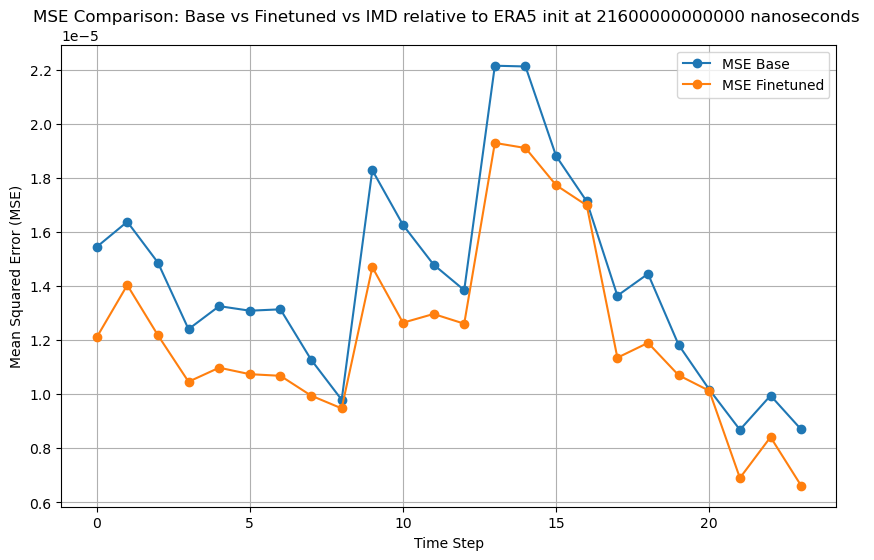

<Figure size 640x480 with 0 Axes>

In [ ]:

assert eval_trial_batches[0].sizes["time"] >= 3

print(f"Eval batch time dimensions: {eval_trial_batches[0].sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


diff_fine, diff_old, diff_hres = [], [], []
for time_step in tqdm(range(forecast_len)):
    diff_fine.append(compute_difference_with_targets_sims(predictions_finetuned,eval_targets,time_step, 'total_precipitation_6hr', plots_dir=plots_dir))
    diff_old.append(compute_difference_with_targets_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr', plots_dir=plots_dir))
    diff_hres.append()


# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

print(mse_base)
print(mse_finetuned)

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

# Annotate the first and last points for MSE Base

# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
plt.clf()
# diff_imd.append(plot_diff_imd_era5

In [39]:
eval_targets.sum(dim='time')['total_precipitation_6hr'].squeeze(dim='batch')

<xarray.DataArray 'total_precipitation_6hr' (lat: 181, lon: 360)> Size: 261kB
array([[0.00084066, 0.00084066, 0.00084066, ..., 0.00084066, 0.00084066,
        0.00084066],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00375437, 0.00364875, 0.00385187, ..., 0.00338937, 0.00360562,
        0.00346937],
       [0.00719025, 0.00712896, 0.00727724, ..., 0.00696879, 0.00719   ,
        0.00726148],
       [0.00448465, 0.00448465, 0.00448465, ..., 0.00448465, 0.00448465,
        0.00448465]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B 0

In [ ]:
# predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india_2023_6.nc")
# predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2023_6.nc")